In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from bgflow.utils import (assert_numpy, distance_vectors, distances_from_vectors, 
                          remove_mean, IndexBatchIterator, LossReporter, as_numpy, compute_distances
)
from bgflow import (GaussianMCMCSampler, DiffEqFlow, BoltzmannGenerator, Energy, Sampler, 
                    MultiDoubleWellPotential, MeanFreeNormalDistribution, 
                    KernelDynamics,BlackBoxDynamics, TimeIndependentDynamics, BruteForceEstimator, HutchinsonEstimator, DenseNet)

from bgflow.utils.autograd import brute_force_jacobian_trace

from tbg.gcl import E_GCL_vel, E_GCL, GCL
from tbg.models2 import EGNN
from tqdm import tqdm

import time

In [3]:
# first define system dimensionality and a target energy/distribution

dim = 8
n_particles = 4
n_dimensions = dim // n_particles

# DW parameters
a=0.9
b=-4
c=0
offset=4

target = MultiDoubleWellPotential(dim, n_particles, a, b, c, offset, two_event_dims=False)

In [4]:
# define a MCMC sampler to sample from the target energy

dw4_data = np.load("data/dw4-dataidx.npy", allow_pickle=True)
all_data = remove_mean(dw4_data[0], n_particles, n_dimensions)
idx = dw4_data[1]
data = all_data[idx[:100000]]
val_data = all_data[idx[100000:500000]]
data_holdout = all_data[idx[-500000:]]
data_holdout.shape

torch.Size([500000, 8])

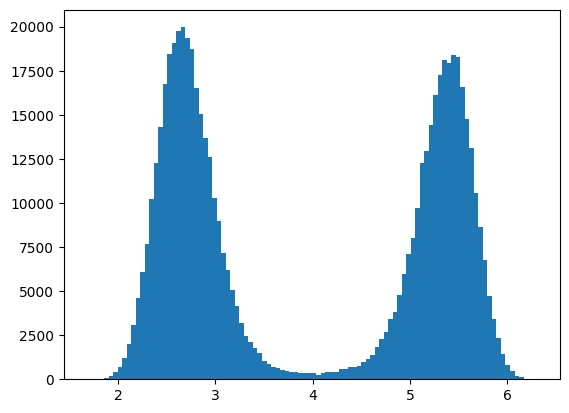

In [5]:
dists_data = as_numpy(compute_distances(data, n_particles, n_dimensions))

plt.hist(dists_data.reshape(-1), bins=100);

In [6]:
n_data = 100000
data_smaller = data[:n_data].clone()
data_smaller = data_smaller
data_smaller.shape

PATH = "models/DW4_equivariant_nODE-egnn-100000"


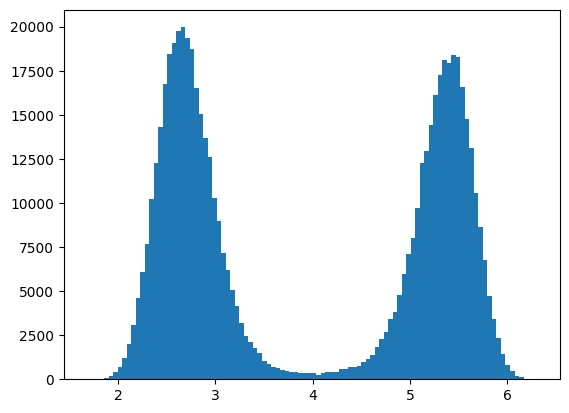

In [7]:
dists_data = as_numpy(compute_distances(data_smaller, n_particles, n_dimensions))

plt.hist(dists_data.reshape(-1), bins=100);

In [8]:
import pdb

# now set up a prior
class MyMeanFreeNormalDistribution(Energy, Sampler):
    """ Mean-free normal distribution. """

    def __init__(self, dim, n_particles, std=1., two_event_dims=True):
        if two_event_dims:
            super().__init__([n_particles, dim // n_particles])
        else:
            super().__init__(dim)
        self._two_event_dims = two_event_dims
        self._dim = dim
        self._n_particles = n_particles
        self._spacial_dims = dim // n_particles
        self.register_buffer("_std", torch.as_tensor(std))

    def forward(self, n_samples, temperature=1.):
        samples = self.sample(n_samples, temperature)
        energy = 0.5 * samples.pow(2).sum(dim=-1, keepdim=True) / self._std ** 2
        return samples, energy.squeeze()
        
    def _energy(self, x):
        x = self._remove_mean(x).view(-1, self._dim)
        # TODO: make consistent
        return 0.5 * x.pow(2).sum(dim=-1, keepdim=True) / self._std ** 2

    def sample(self, n_samples, temperature=1.):
        x = torch.ones((n_samples, self._n_particles, self._spacial_dims), dtype=self._std.dtype,
                         device=self._std.device).normal_(mean=0, std=self._std)
        x = self._remove_mean(x)
        if not self._two_event_dims:
            x = x.view(-1, self._dim)
        return x

    def _remove_mean(self, x):
        x = x.view(-1, self._n_particles, self._spacial_dims)
        x = x - torch.mean(x, dim=1, keepdim=True)
        return x



prior =  MyMeanFreeNormalDistribution(dim, n_particles, two_event_dims=False).cuda()

In [9]:
from tbg.utils import remove_mean as tbg_remove_mean

class EGNN_dynamics_consistency(nn.Module):
    def __init__(
        self,
        n_particles,
        n_dimension,
        hidden_nf=64,
        device="cpu",
        act_fn=torch.nn.SiLU(),
        n_layers=4,
        recurrent=True,
        attention=False,
        condition_time=True,
        tanh=False,
        mode="egnn_dynamics",
        agg="sum",
    ):
        super().__init__()
        self.mode = mode
        if mode == "egnn_dynamics":
            self.egnn = EGNN(
                in_node_nf=2,
                in_edge_nf=1,
                hidden_nf=hidden_nf,
                device=device,
                act_fn=act_fn,
                n_layers=n_layers,
                recurrent=recurrent,
                attention=attention,
                tanh=tanh,
                agg=agg,
            )

        self.device = device
        self._n_particles = n_particles
        self._n_dimension = n_dimension
        self.edges = self._create_edges()
        self._edges_dict = {}
        self.condition_time = condition_time
        # Count function calls
        self.counter = 0

    def forward(self, t, xs, d=None):

        n_batch = xs.shape[0]
        edges = self._cast_edges2batch(self.edges, n_batch, self._n_particles)
        edges = [edges[0], edges[1]]
        x = xs.reshape(n_batch * self._n_particles, self._n_dimension).clone()
        h = torch.ones(n_batch, self._n_particles, 2).to(self.device)
        t = torch.tensor(t).to(xs)
        if t.shape != (n_batch, 1):
            t = t.repeat(n_batch)
        t = t.reshape(n_batch, 1)
        if d is None:
            d = torch.zeros_like(t)

        td = torch.cat([t, d], dim=-1)
        if self.condition_time:
            h = h * td.unsqueeze(1)
        h = h.reshape(n_batch * self._n_particles, 2)
        if self.mode == "egnn_dynamics":
            edge_attr = torch.sum((x[edges[0]] - x[edges[1]]) ** 2, dim=1, keepdim=True)
            _, x_final = self.egnn(h, x, edges, edge_attr=edge_attr)
            vel = x_final - x

        elif self.mode == "gnn_dynamics":
            h = torch.cat([h, x], dim=1)
            vel = self.gnn(h, edges)

        vel = vel.view(n_batch, self._n_particles, self._n_dimension)
        vel = tbg_remove_mean(vel)
        self.counter += 1
        return vel.view(n_batch, self._n_particles * self._n_dimension)

    def _create_edges(self):
        rows, cols = [], []
        for i in range(self._n_particles):
            for j in range(i + 1, self._n_particles):
                rows.append(i)
                cols.append(j)
                rows.append(j)
                cols.append(i)
        return [torch.LongTensor(rows), torch.LongTensor(cols)]

    def _cast_edges2batch(self, edges, n_batch, n_nodes):
        if n_batch not in self._edges_dict:
            self._edges_dict = {}
            rows, cols = edges
            rows_total, cols_total = [], []
            for i in range(n_batch):
                rows_total.append(rows + i * n_nodes)
                cols_total.append(cols + i * n_nodes)
            rows_total = torch.cat(rows_total).to(self.device)
            cols_total = torch.cat(cols_total).to(self.device)

            self._edges_dict[n_batch] = [rows_total, cols_total]
        return self._edges_dict[n_batch]    

In [42]:
import normflows as nf
import larsflow as lf
from fab.wrappers.normflows import WrappedNormFlowModel
from fab.trainable_distributions import TrainableDistribution
import pdb

def make_normflow_flow(dim: int,
                       n_flow_layers: int,
                       layer_nodes_per_dim: int,
                       act_norm: bool):
    # Define list of flows
    flows = []
    layer_width = dim * layer_nodes_per_dim
    for i in range(n_flow_layers):
        # Neural network with two hidden layers having 32 units each
        # Last layer is initialized by zeros making training more stable
        d = int((dim / 2) + 0.5)
        param_map = nf.nets.MLP([d, layer_width, layer_width, 2 * (dim - d)], init_zeros=True)
        # Add flow layer
        flows.append(nf.flows.AffineCouplingBlock(param_map, scale_map="exp"))
        # Swap dimensions
        flows.append(nf.flows.InvertibleAffine(dim))
        # ActNorm
        if act_norm:
            flows.append(nf.flows.ActNorm(dim))
    return flows

def make_wrapped_normflow_realnvp(
        dim: int,
        n_flow_layers: int = 5,
        layer_nodes_per_dim: int = 10,
        act_norm: bool = True) -> TrainableDistribution:
    """Created a wrapped normflows distribution using the example from the normflows page."""
    base = prior
    flows = make_normflow_flow(dim, n_flow_layers=n_flow_layers,
                               layer_nodes_per_dim=layer_nodes_per_dim,
                               act_norm=act_norm)
    model = nf.NormalizingFlow(base, flows).cuda()
    wrapped_dist = WrappedNormFlowModel(model)
    if act_norm:
        wrapped_dist.sample((500,))  # ensure we call sample to initialise the ActNorm layers
    return wrapped_dist

class ComboModel(torch.nn.Module):
    def __init__(self, coupling_flow, flow_model):
        super().__init__()
        self.coupling_flow = coupling_flow
        self.flow_model = flow_model
        
    def forward(self, dt, xs, d=None):
        use_coupling_flow = d == 0
        # v_coupling_flow = self.coupling_flow._nf_model.inverse(xs)
        v_flow = self.flow_model(dt[:, None], xs, d[:, None])
        return v_flow
        #return torch.where(use_coupling_flow[:,None], v_coupling_flow, v_flow)


net_dynamics = EGNN_dynamics_consistency(n_particles=n_particles, device='cuda',  n_dimension=dim // n_particles, hidden_nf=32,
    act_fn=torch.nn.SiLU(), n_layers=3, recurrent=True, tanh=True, attention=True, condition_time=True, mode='egnn_dynamics', agg='sum')

realnvp = make_wrapped_normflow_realnvp(8)
combo_model = ComboModel(realnvp, net_dynamics).cuda()

In [43]:
# Initialize divergence estimators
brute_force_estimator = BruteForceEstimator()

In [44]:
# bb_dynamics = BlackBoxDynamics(
#     dynamics_function=net_dynamics,
#     divergence_estimator=brute_force_estimator
# )
bb_dynamics = BlackBoxDynamics(
    dynamics_function=net_dynamics,
    divergence_estimator=brute_force_estimator
)

In [45]:
flow = DiffEqFlow(
    dynamics=bb_dynamics
)

In [46]:
# having a flow and a prior, we can now define a Boltzmann Generator

bg = BoltzmannGenerator(prior, flow, target).cuda()

In [47]:
# use DTO in the training process
flow._use_checkpoints = True

# Anode options
options={
    "Nt": 20,
    "method": "RK4"
}
flow._kwargs = options

In [48]:
# train with convex mixture of NLL and KL loss

n_kl_samples = 256
n_batch = 256
batch_iter = IndexBatchIterator(len(data_smaller), n_batch)
print(len(data_smaller))
optim = torch.optim.AdamW(combo_model.parameters(), lr=5e-4, weight_decay=0.1)

n_epochs = 10
n_report_steps = 5

# mixing parameter

reporter = LossReporter("NLL", "Consistency")
val_losses = []

100000


In [49]:
# start with 5e-4
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
M = 128
bootstrap_every = 8
log2_sections = np.log2(M).astype(np.int32)

for g in optim.param_groups:
     g['lr'] = 5e-4

In [ ]:
import pdb

def get_targets(model,
                images, 
                force_t=-1, 
                force_dt=-1):

    device = images.device  # Or wherever you’d like your tensors to live (cuda, cpu, etc.)
    info = {}

    # -----------------------------------------------------------------
    #  1) =========== Sample dt. ============
    # -----------------------------------------------------------------
    bootstrap_batchsize = batch_size // bootstrap_every
    log2_sections = int(np.log2(M))

    dt_range = torch.arange(log2_sections, device=device, dtype=torch.int32)  # [0, 1, 2, ..., log2_sections-1]
    dt_array = (log2_sections - 1 - dt_range)  # e.g. [log2_sections-1, ..., 0]
    repeated = dt_array.repeat(bootstrap_batchsize // log2_sections)
    needed = bootstrap_batchsize - repeated.shape[0]
    dt_base = torch.cat([repeated, torch.zeros(needed, device=device, dtype=torch.int32)], dim=0)

    force_dt_vec = torch.ones(bootstrap_batchsize, device=device, dtype=torch.float32) * force_dt
    dt_base = dt_base.to(torch.float32)  # cast to float to match usage below
    dt_base = torch.where(force_dt_vec != -1, force_dt_vec, dt_base)  # if force_dt != -1, use that

    # dt = 1 / (2^(dt_base)) 
    dt = 1.0 / (2.0 ** dt_base)

    dt_base_bootstrap = dt_base + 1.0
    dt_bootstrap = dt / 2.0
    pdb.set_trace()
    # -----------------------------------------------------------------
    #  2) =========== Sample t. ============
    # -----------------------------------------------------------------
    dt_sections = 2.0 ** dt_base
    # We want to sample t ~ Uniform{0, dt_sections[i]} (integer), then divide by dt_sections[i].
    # This is somewhat trickier to do in a single vectorized call in PyTorch 
    # (because each batch element can have a different max). 
    # We'll do it in a loop for clarity:

    t_list = []
    for i in range(bootstrap_batchsize):
        maxval = int(dt_sections[i].item())  # dt_sections[i] is float, convert to int
        # If maxval == 0 for some reason, clamp to 1 to avoid errors
        if maxval < 1:
            maxval = 1
        # Sample an integer in [0, maxval)
        t_i = torch.randint(low=0, high=maxval, size=(1,), device=device, dtype=torch.int64)
        t_list.append(t_i)

    t = torch.cat(t_list, dim=0).to(torch.float32)      # shape [bootstrap_batchsize]
    t = t / dt_sections                                 # elementwise scale to [0, 1]

    # force_t logic
    force_t_vec = torch.ones(bootstrap_batchsize, device=device, dtype=torch.float32) * force_t
    t = torch.where(force_t_vec != -1, force_t_vec, t)
    t_full = t.view(-1, 1)

    # -----------------------------------------------------------------
    #  3) =========== Generate Bootstrap Targets ============
    # -----------------------------------------------------------------
    x_1 = images[:bootstrap_batchsize]
    x_0 = torch.randn_like(x_1)
    x_t = (1.0 - (1.0 - 1e-5) * t_full) * x_0 + t_full * x_1

    with torch.no_grad():
        v_b1 = combo_model(t, x_t, dt_base_bootstrap)
            
    t2 = t + dt_bootstrap
    x_t2 = x_t + dt_bootstrap.view(-1, 1) * v_b1
    # x_t2 = torch.clamp(x_t2, -4.0, 4.0)

    with torch.no_grad():
        v_b2 = combo_model(t2, x_t2, dt_base_bootstrap)
        # v_b2 = model(torch.cat([x_t2, t2[:, None], dt_base_bootstrap[:, None]], dim=-1))

    v_target = 0.5 * (v_b1 + v_b2)
    #v_target = torch.clamp(v_target, -4.0, 4.0)

    bst_v = v_target
    bst_dt = dt_base
    bst_t = t
    bst_xt = x_t

    # -----------------------------------------------------------------
    #  4) =========== Generate Flow-Matching Targets ============
    # -----------------------------------------------------------------


    # Sample t uniformly in [0, denoise_timesteps), then / denoise_timesteps
    t_rand = torch.randint(0, M, (images.shape[0],), device=device)
    t_float = t_rand.to(torch.float32) / M

    force_t_vec = torch.ones(images.shape[0], device=device, dtype=torch.float32) * force_t
    t_float = torch.where(force_t_vec != -1, force_t_vec, t_float)
    t_full = t_float.view(-1, 1)

    # x_0 ~ N(0, 1)
    x_0 = torch.randn_like(images)
    x_1 = images

    # x_t = (1 - alpha * t) * x_0 + t * x_1  (with alpha=1-1e-5 in your code)
    x_t_flow = (1.0 - (1.0 - 1e-5) * t_full) * x_0 + t_full * x_1
    v_t_flow = x_1 - (1.0 - 1e-5) * x_0

    dt_flow = int(np.log2(M))
    dt_base_flow = torch.ones(images.shape[0], device=device, dtype=torch.int32) * dt_flow

    # -----------------------------------------------------------------
    #  5) =========== Merge Flow + Bootstrap =============
    # -----------------------------------------------------------------
    bst_size = batch_size // bootstrap_every
    bst_size_data = batch_size - bst_size

    # Combine the bootstrap slices with the flow slices
    x_t_final = torch.cat([bst_xt, x_t_flow[:bst_size_data]], dim=0)
    t_final = torch.cat([bst_t, t_float[:bst_size_data]], dim=0)
    dt_base_final = torch.cat([bst_dt, dt_base_flow[:bst_size_data]], dim=0)
    v_t_final = torch.cat([bst_v, v_t_flow[:bst_size_data]], dim=0)

    # A few diagnostics
    info["bootstrap_ratio"] = torch.mean((dt_base_final != dt_flow).float())
    info["v_magnitude_bootstrap"] = torch.sqrt(torch.mean(bst_v**2))
    info["v_magnitude_b1"] = torch.sqrt(torch.mean(v_b1**2))
    info["v_magnitude_b2"] = torch.sqrt(torch.mean(v_b2**2))

    return x_t_final, v_t_final, t_final, dt_base_final, info


for epoch in tqdm(range(n_epochs)):
    if epoch ==200:
        for g in optim.param_groups:
             g['lr'] = 5e-5
    for it, idxs in enumerate(batch_iter):
        optim.zero_grad()
        x_1 = data_smaller[idxs].cuda()
        batch_size = x_1.shape[0]
    
        x_t_final, v_t_final, t_final, dt_base_final, info = get_targets(combo_model, x_1)
        v_t_pred = combo_model(t_final, x_t_final, dt_base_final)
        # v_t_pred = model(torch.cat([x_t_final, t_final[:, None], dt_base_final[:, None]], dim=-1))
        flow_loss = torch.mean((v_t_pred - v_t_final) ** 2, dim=-1)
        loss = flow_loss.mean()
        loss.backward()
        bootstrap_size = batch_size // bootstrap_every
        info['loss_flow'] = torch.mean(flow_loss[bootstrap_size:]).item()
        info['loss_bootstrap'] = torch.mean(flow_loss[:bootstrap_size]).item()
        optim.step()
    
    if epoch % n_report_steps == 0:
        print(f"Epoch: {epoch} Step [{it}/{len(batch_iter)}] - Flow Loss: {info['loss_flow']:.4f} Bootstrap Loss: {info['loss_bootstrap']:.4f} ")
        

  0%|                                                                                                                                                                                                                                                                                                                                                | 0/10 [00:00<?, ?it/s]

> /tmp/ipykernel_819714/1771680938.py(36)get_targets()
     34     #  2) =========== Sample t. ============
     35     # -----------------------------------------------------------------
---> 36     dt_sections = 2.0 ** dt_base
     37     # We want to sample t ~ Uniform{0, dt_sections[i]} (integer), then divide by dt_sections[i].
     38     # This is somewhat trickier to do in a single vectorized call in PyTorch



ipdb>  p dt_base_bootstrap


tensor([7., 6., 5., 4., 3., 2., 1., 7., 6., 5., 4., 3., 2., 1., 7., 6., 5., 4.,
        3., 2., 1., 7., 6., 5., 4., 3., 2., 1., 1., 1., 1., 1.],
       device='cuda:0')


ipdb>  p images.shape


torch.Size([256, 8])


ipdb>  p bootstrap_batchsize


32


ipdb>  ll


      3 def get_targets(model,
      4                 images,
      5                 force_t=-1,
      6                 force_dt=-1):
      7 
      8     device = images.device  # Or wherever you’d like your tensors to live (cuda, cpu, etc.)
      9     info = {}
     10 
     11     # -----------------------------------------------------------------
     12     #  1) =========== Sample dt. ============
     13     # -----------------------------------------------------------------
     14     bootstrap_batchsize = batch_size // bootstrap_every
     15     log2_sections = int(np.log2(M))
     16 
     17     dt_range = torch.arange(log2_sections, device=device, dtype=torch.int32)  # [0, 1, 2, ..., log2_sections-1]
     18     dt_array = (log2_sections - 1 - dt_range)  # e.g. [log2_sections-1, ..., 0]
     19     repeated = dt_array.repeat(bootstrap_batchsize // log2_sections)
     20     needed = bootstrap_batchsize - repeated.shape[0]
     21     dt_base = torch.cat([repeated, tor

In [19]:
# d_values = torch.tensor([1/128, 1/64, 1/32, 1/16,1/8,1/4, 1/2])

In [20]:

# train_ot = True
# if train_ot == True:

#     sigma = 0.01
#     for epoch in range(n_epochs):
#         if epoch ==200:
#             for g in optim.param_groups:
#                  g['lr'] = 5e-5
#         for it, idxs in enumerate(batch_iter):

#             optim.zero_grad()
#             x1 = data_smaller[idxs].cuda()
#             batchsize = x1.shape[0]
#             t = torch.rand(batchsize, 1).cuda()
#             indices = torch.randint(0, len(d_values), (batchsize,))
#             d = d_values[indices].unsqueeze(-1).cuda()
#             d_input = d.clone()
#             d_input[d_input<1/100] = 0
            
#             x0 = prior.sample(batchsize)

#             mu_t = x0 * (1 - t) + x1 * t
#             sigma_t = sigma
#             noise = prior.sample(batchsize)
#             x = mu_t + sigma_t * noise
            
#             ut = x1 - x0
#             print(t.shape, x.shape, d_input.shape)
#             vt = bg.flow._dynamics._dynamics._dynamics_function(t, x)
#             loss = torch.mean((vt - ut) ** 2)
#             loss.backward()
#             s_t = bg.flow._dynamics._dynamics._dynamics_function(t, x, d_input)
#             # use mu_t here directly?
#             x_td = x + s_t * d
#             s_td = bg.flow._dynamics._dynamics._dynamics_function(t+d, x_td, d_input)
#             s_target = (s_t + s_td).detach() / 2
#             v_td = bg.flow._dynamics._dynamics._dynamics_function(t, x, 2*d)
#             consistency_loss = torch.mean((v_td - s_target) ** 2)
#             consistency_loss.backward()
#             optim.step()
#             reporter.report(loss, consistency_loss)

#             if it % n_report_steps == 0:
#                 print("\repoch: {0}, iter: {1}/{2}, loss: {3:.4}, consistency_loss: {4:.4}".format(
#                         epoch,
#                         it,
#                         len(batch_iter),
#                         *reporter.recent(1).ravel()
#                     ), end="")

ValueError: v cannot be empty

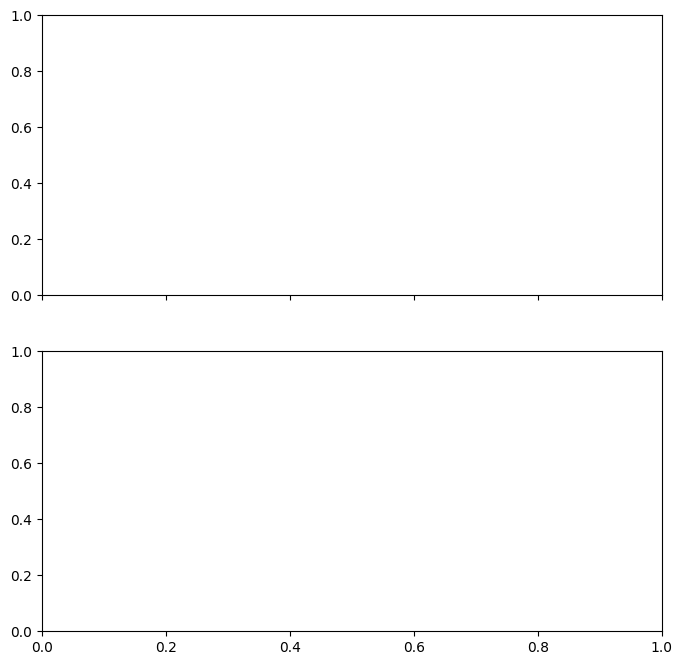

In [21]:
reporter.plot()

In [51]:
sum(p.numel() for p in bg.parameters() if p.requires_grad)

22533

In [22]:
PATH = "models/DW4_shortcut_copy"
torch.save(combo_model.state_dict(), PATH)
combo_model.load_state_dict(torch.load(PATH))

/tmp/ipykernel_819714/107046593.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  combo_model.load_state_dict(torch.load(PATH))


<All keys matched successfully>

In [52]:

class BruteForceEstimatorFast(torch.nn.Module):
    """
    Exact bruteforce estimation of the divergence of a dynamics function.
    """

    def __init__(self):
        super().__init__()

    def forward(self, dynamics, t, xs):
        """
        Computes the change of the system `dxs` due to a time independent dynamics function.
        Furthermore, also computes the exact change of log density
        which is equal to the divergence of the change `dxs`.

        Parameters
        ----------
        dynamics : torch.nn.Module
            A dynamics function that computes the change of the system and its density.
        t : PyTorch tensor
            The current time
        xs : PyTorch tensor
            The current configuration of the system

        Returns
        -------
        dxs, -divergence: PyTorch tensors
            The combined state update of shape `[n_batch, n_dimensions]`
            containing the state update of the system state `dx/dt`
            (`dxs`) and the negative update of the log density (`-divergence`)
        """

        with torch.set_grad_enabled(True):
            xs.requires_grad_(True)
            x = [xs[:, [i]] for i in range(xs.size(1))]

            dxs = dynamics(t, torch.cat(x, dim=1))

            assert len(dxs.shape) == 2, "`dxs` must have shape [n_btach, system_dim]"
            divergence = 0
            for i in range(xs.size(1)):
                divergence += torch.autograd.grad(dxs[:, [i]], x[i], torch.ones_like(dxs[:, [i]]), retain_graph=True)[0]

        return dxs, -divergence.view(-1, 1)
    
brute_force_estimator_fast = BruteForceEstimatorFast()
# use OTD in the evaluation process
bb_dynamics._divergence_estimator = brute_force_estimator_fast
bg.flow._integrator_atol = 1e-3
bg.flow._integrator_rtol = 1e-3
flow._use_checkpoints = False

## Sampling with dopri5

In [53]:

n_samples = 1000
n_sample_batches = 50
latent_np = np.empty(shape=(0))
samples_np = np.empty(shape=(0))
log_w_np = np.empty(shape=(0))
energies_np = np.empty(shape=(0))
distances_x_np = np.empty(shape=(0))

for i in tqdm(range(n_sample_batches)):
    with torch.no_grad():
        samples, latent, dlogp = bg.sample(n_samples, with_latent=True, with_dlogp=True)
        #latent = latent[0]
        log_weights = bg.log_weights_given_latent(samples, latent, dlogp, normalize=False).detach().cpu().numpy()
        latent_np = np.append(latent_np, latent.detach().cpu().numpy())
        samples_np = np.append(samples_np, samples.detach().cpu().numpy())
        distances_x = distances_from_vectors(distance_vectors(samples.view(-1, n_particles, n_dimensions))).detach().cpu().numpy().reshape(-1)
        distances_x_np = np.append(distances_x_np, distances_x)

        log_w_np = np.append(log_w_np, log_weights)
        energies = target.energy(samples).detach().cpu().numpy()
        energies_np = np.append(energies_np, energies)
        

latent_np = latent_np.reshape(-1, dim)
samples_np = samples_np.reshape(-1, dim)

/tmp/ipykernel_819714/953134320.py:51: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).                                                                                                           | 0/50 [00:00<?, ?it/s]
  t = torch.tensor(t).to(xs)
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:45<00:00,  1.11it/s]


In [55]:
from bgflow.bg import sampling_efficiency
sampling_efficiency(torch.from_numpy(log_w_np)).item()

4.1422198400177733e-05

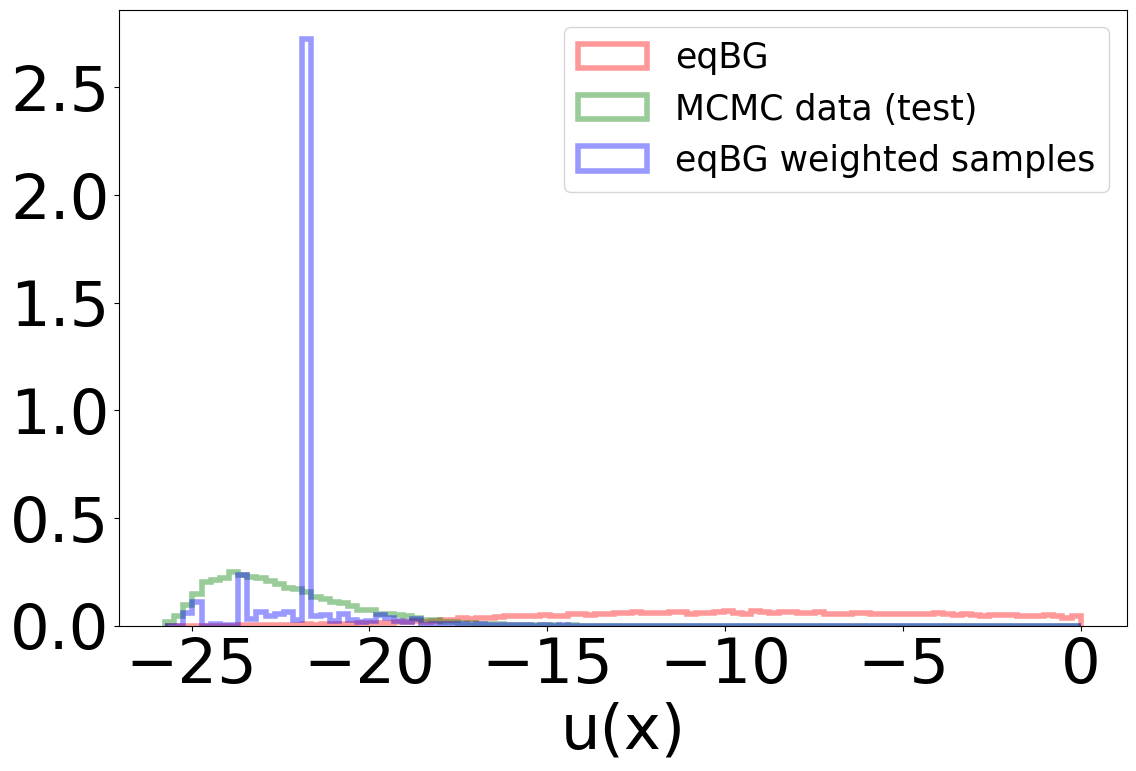

In [56]:
energies_data = target.energy(data).detach().cpu().numpy()
#energies_compare = sampls.energy()
energies_bg = energies_np#target.energy(samples[:, :dim]).detach().cpu().numpy()

energies_prior = target.energy(latent).detach().cpu().numpy()

min_energy = min(energies_data.min(), energies_bg.min(), energies_prior.min())
max_energy = max(energies_data.max(), energies_bg.max(), energies_prior.max())

plt.figure(figsize=(13,8))
efac = 1
#plt.hist(energies_prior, bins=100, density=True, range=(min_energy, 0), alpha=0.4, color="b", histtype='step', linewidth=4,
#         label="prior");
plt.hist(energies_bg, bins=100, density=True,  range=(min_energy, 0), alpha=0.4, histtype='step', linewidth=4,
         color="r", label="eqBG");

plt.hist(energies_data, bins=100, density=True, range=(min_energy, 0), alpha=0.4, color="g", histtype='step', linewidth=4, 
         label="MCMC data (test)");
plt.hist(energies_bg.reshape(-1), bins=100, density=True,  range=(min_energy, 0), alpha=0.4, histtype='step', linewidth=4,
         color="b", label="eqBG weighted samples", weights=np.exp(log_w_np));
#plt.hist(energies_compare, bins=100, density=True, range=(energies_bg.min(), 0), alpha=0.4, color="y", 
#         label="MCMC data (test)");

plt.xlabel("u(x)", fontsize=45)  
plt.xticks(fontsize=45) 
plt.yticks(fontsize=45);
plt.legend( fontsize=25);

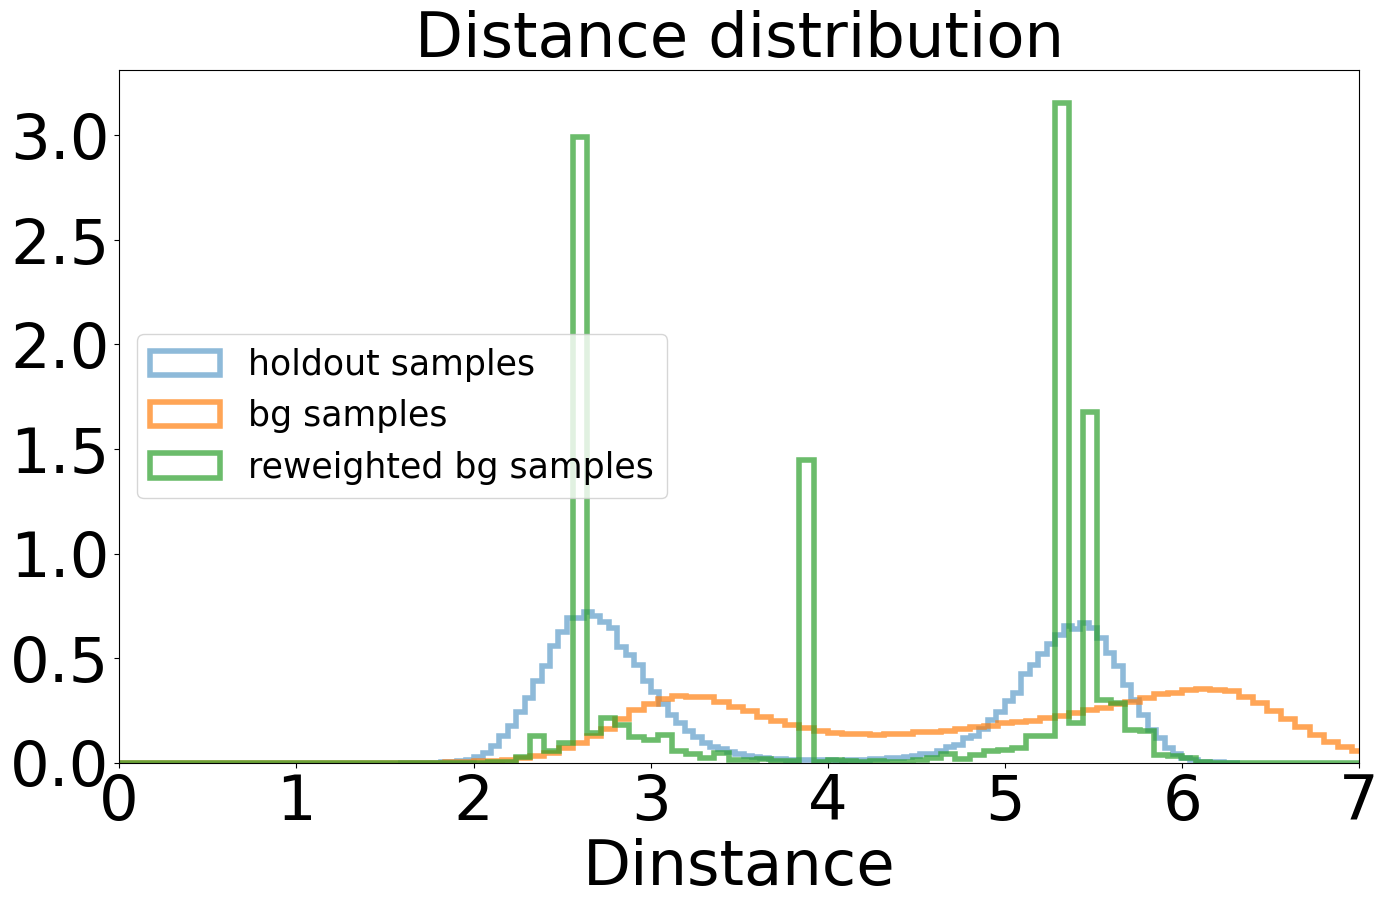

In [58]:
dists = distances_from_vectors(
            distance_vectors(data_holdout.view(-1, n_particles, dim // n_particles)))
dists_prior = distances_from_vectors(
            distance_vectors(latent.view(-1, n_particles, dim // n_particles)))
from bgflow.utils import as_numpy
def distance_energy(d):
    d = d - offset
    return c * d**4 + b * d**2
d = torch.linspace(1, 7, 1000).view(-1, 1) + 1e-6 
u = torch.exp(-(distance_energy(d).view(-1, 1) - offset )).sum(dim=-1, keepdim=True)  * d.abs() **(dim // n_particles - 1)
Z = (u * 1 / (len(d) / (d.max() - d.min()))).sum()
e = u / Z #* 1.1

plt.figure(figsize=(16,9))
#plt.plot(d, e, label="Groundtruth", linewidth=4, alpha = 0.5)
plt.hist(as_numpy(dists.view(-1)), bins=100, label="holdout samples", alpha=0.5, density=True, histtype='step', linewidth=4);
plt.hist(distances_x_np, bins=100, label="bg samples", alpha=0.7, density=True, histtype='step', linewidth=4, range=(0,8));
plt.hist(distances_x_np, bins=100, label="reweighted bg samples", alpha=0.7, density=True, histtype='step',
         linewidth=4, weights=np.repeat(np.exp(log_w_np).flatten(), n_particles*(n_particles-1)), range=(0,8));
plt.xlim(0,7)
plt.legend(fontsize=25)
plt.xlabel("Dinstance", fontsize=45)  
plt.xticks(fontsize=45) 
plt.yticks(fontsize=45);
plt.title("Distance distribution", fontsize=45);


In [59]:
# count the steps here

bb_dynamics._dynamics_function.counter = 0
with torch.no_grad():
    samples, latent, dlogp = bg.sample(n_samples, with_latent=True, with_dlogp=True)
bb_dynamics._dynamics_function.counter

/tmp/ipykernel_819714/953134320.py:51: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t).to(xs)


26

# Sampling with shortcut models

In [60]:
# inference with Euler
def euler_solve(model, x0, n_steps):
    """
    model: nn.Module representing v(x,t)
    x0: (batch_size, input_dim) initial samples from p0(x)
    T: end time
    N: number of Euler steps
    """
    N = n_steps
    x = x0
    t = torch.zeros(x0.shape[0]).to(x0)
    dt = torch.tensor(1/ N).to(x0)[None]
    dt_flow = torch.ones(x0.shape[0]).to(x0) * int(np.log2(n_steps))

    for step in range(N):
        # Forward Euler update
        with torch.no_grad():
            dx = model(t, x, dt_flow)  # v(x, t)
            x = x + dt * dx   # x_{k+1} = x_k + dt * v(x_k, t_k)
            t = t + dt        # increment time

    return x


In [61]:
x0 = prior.sample(10000)

log2_sections = int(np.log2(M)) + 1
dt_range = torch.arange(log2_sections, device=device, dtype=torch.int32).flip(dims=(0,))
dt_range
n_steps = 2

In [62]:
x1 = euler_solve(combo_model, x0=x0, n_steps=n_steps)


/tmp/ipykernel_819714/953134320.py:51: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t).to(xs)


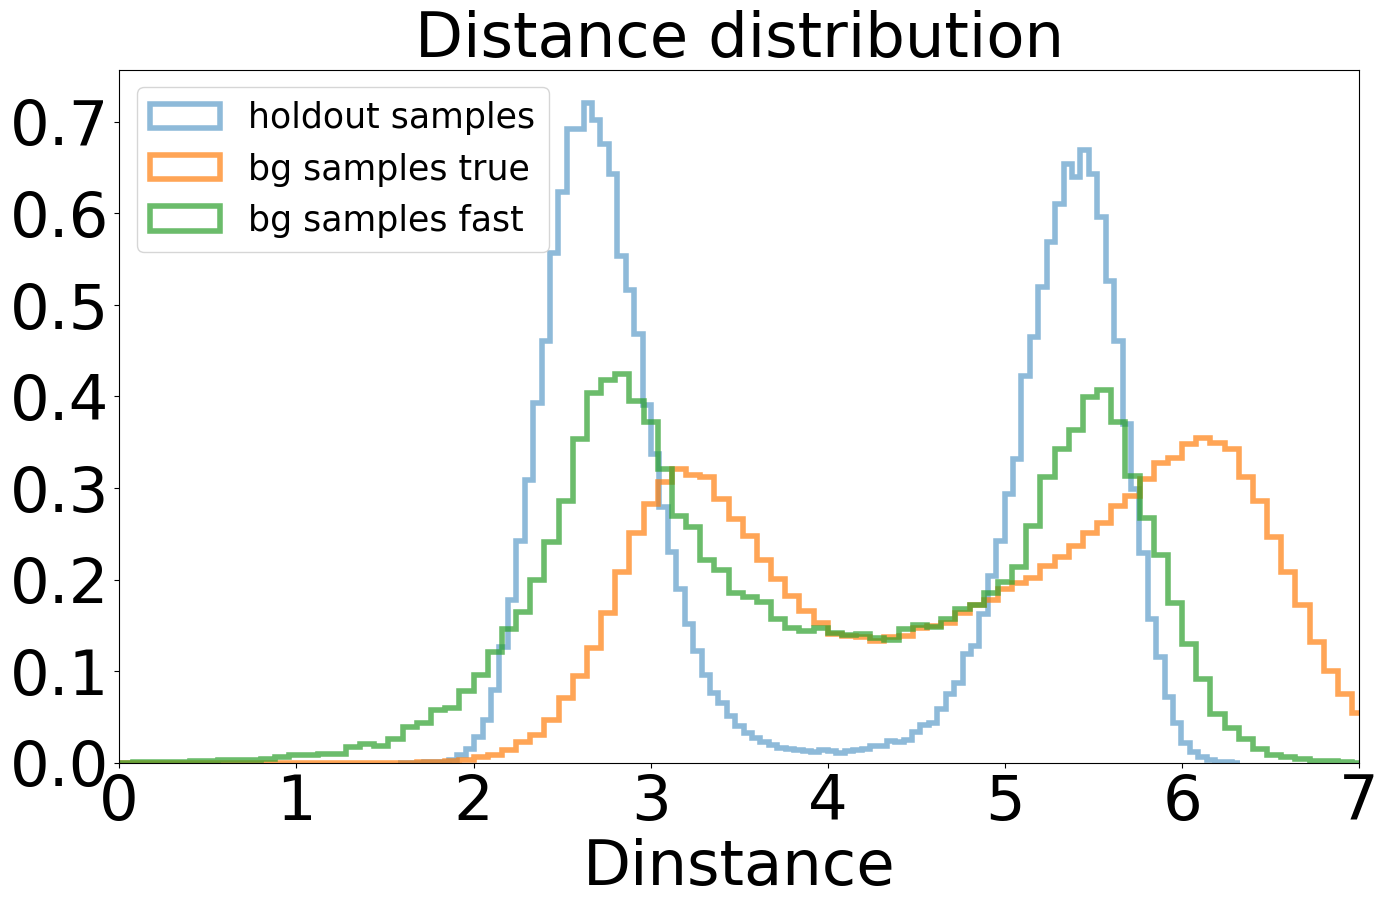

In [63]:
plt.figure(figsize=(16,9))
distances_x_fast = distances_from_vectors(distance_vectors(x1.view(-1, n_particles, n_dimensions))).detach().cpu().numpy().reshape(-1)

plt.hist(as_numpy(dists.view(-1)), bins=100, label="holdout samples", alpha=0.5, density=True, histtype='step', linewidth=4);
plt.hist(distances_x_np, bins=100, label="bg samples true", alpha=0.7, density=True, histtype='step', linewidth=4, range=(0,8));
plt.hist(distances_x_fast, bins=100, label="bg samples fast", alpha=0.7, density=True, histtype='step', linewidth=4, range=(0,8));

plt.xlim(0,7)
plt.legend(fontsize=25)
plt.xlabel("Dinstance", fontsize=45)  
plt.xticks(fontsize=45) 
plt.yticks(fontsize=45);
plt.title("Distance distribution", fontsize=45);


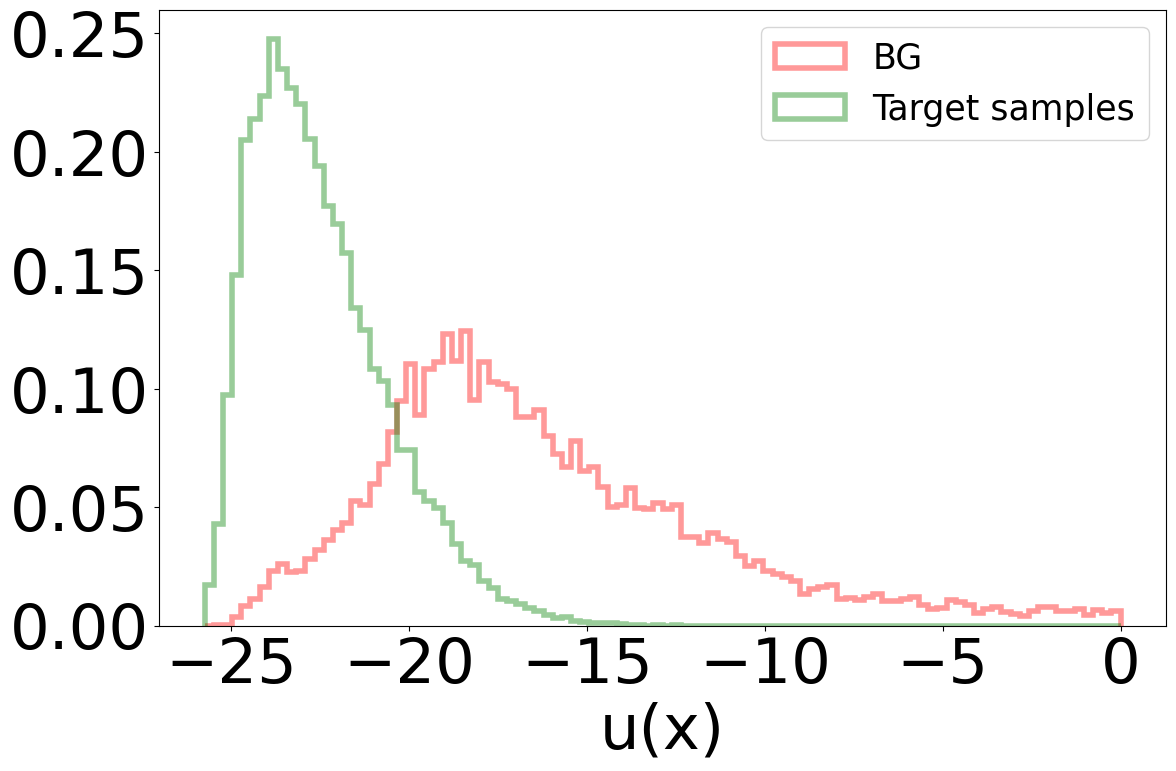

In [64]:
energies_data = target.energy(data).detach().cpu().numpy()
#energies_compare = sampls.energy()
energies_bg = target.energy(x1).detach().cpu().numpy()

energies_prior = target.energy(latent).detach().cpu().numpy()

min_energy = min(energies_data.min(), energies_bg.min(), energies_prior.min())
max_energy = max(energies_data.max(), energies_bg.max(), energies_prior.max())

plt.figure(figsize=(13,8))
efac = 1

plt.hist(energies_bg, bins=100, density=True,  range=(min_energy, 0), alpha=0.4, histtype='step', linewidth=4,
         color="r", label="BG");

plt.hist(energies_data, bins=100, density=True, range=(min_energy, 0), alpha=0.4, color="g", histtype='step', linewidth=4, 
         label="Target samples");


plt.xlabel("u(x)", fontsize=45)  
plt.xticks(fontsize=45) 
plt.yticks(fontsize=45);
plt.legend( fontsize=25);

## Including the likelihood

In [65]:
from bgflow import BlackBoxDynamics, TimeIndependentDynamics, BruteForceEstimator, HutchinsonEstimator, DenseNet
from bgflow.utils.autograd import brute_force_jacobian_trace
import torch


class BruteForceEstimatorFastStep(torch.nn.Module):
    """
    Exact bruteforce estimation of the divergence of a dynamics function.
    """

    def __init__(self):
        super().__init__()

    def forward(self, dynamics, t, xs, s):
        """
        Computes the change of the system `dxs` due to a time independent dynamics function.
        Furthermore, also computes the exact change of log density
        which is equal to the divergence of the change `dxs`.

        Parameters
        ----------
        dynamics : torch.nn.Module
            A dynamics function that computes the change of the system and its density.
        t : PyTorch tensor
            The current time
        xs : PyTorch tensor
            The current configuration of the system
        s : PyTorch tensor
            The step size
        Returns
        -------
        dxs, -divergence: PyTorch tensors
            The combined state update of shape `[n_batch, n_dimensions]`
            containing the state update of the system state `dx/dt`
            (`dxs`) and the negative update of the log density (`-divergence`)
        """

        with torch.set_grad_enabled(True):
            xs.requires_grad_(True)
            x = [xs[:, [i]] for i in range(xs.size(1))]

            dxs = dynamics(t, torch.cat(x, dim=1), s)

            assert len(dxs.shape) == 2, "`dxs` must have shape [n_btach, system_dim]"
            divergence = 0
            for i in range(xs.size(1)):
                divergence += torch.autograd.grad(dxs[:, [i]], x[i], torch.ones_like(dxs[:, [i]]), retain_graph=True)[0]

        return dxs, divergence.view(-1, 1)
    
brute_force_estimator_fast_step = BruteForceEstimatorFastStep()


In [66]:
def euler_solve_with_logp(model, divergence, x0, n_steps, use_shortcut=True):
    """
    model:   nn.Module that computes v(x, t).
    x0:      (batch_size, dim) initial samples.
    logp0:   (batch_size,) initial log p(x0).
    T:       final time.
    N:       number of Euler steps.

    Returns:
        xN:    (batch_size, dim) final samples at t=T.
        logpN: (batch_size,) log probability of xN.
    """
    N = n_steps
    x = x0
    logp = torch.zeros(x0.shape[0],1).to(x)
    t = torch.zeros(x0.shape[0]).to(x0)
    dt = torch.tensor(1/ N).to(x0)[None]
    dt_flow = torch.ones(x0.shape[0]).to(x0) * int(np.log2(n_steps))

    for _ in range(N):
        # Make sure x is differentiable so we can compute div
        x.requires_grad_(True)
        # 2. Compute velocity and divergence
        v, div_v = divergence(model, t, x, dt_flow if use_shortcut else None)

        # 3. Euler update for x
        x_next = x + dt * v

        # 4. Euler update for log p
        # d/dt [log p] = - div(v), so forward Euler => logp_next = logp - dt * div_v
        logp_next = logp - dt * div_v

        # Detach x_next & logp_next to avoid building huge graphs
        x = x_next.detach()
        logp = logp_next.detach()

        # Increase time
        t = t + dt
    return x, logp


def flow_logp(model):
    x, logp = model.coupling_flow.sample_and_log_prob([10_000])
    
    return x, logp

x1, dlogp1 = flow_logp(combo_model)

In [67]:
dlogp1.max()

tensor(12.4354, device='cuda:0', grad_fn=<MaxBackward1>)

In [38]:
n_steps = 1
# x1, dlogp1 = euler_solve_with_logp(combo_model, brute_force_estimator_fast_step, x0=x0, n_steps=n_steps)
n_steps = 128
x1_normal, dlogp1_normal = euler_solve_with_logp(combo_model, brute_force_estimator_fast_step, x0=x0, n_steps=n_steps)


/tmp/ipykernel_819714/953134320.py:51: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t).to(xs)


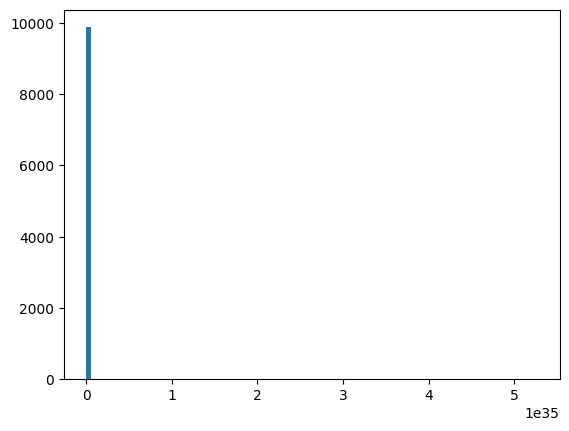

In [39]:
plt.hist(as_numpy(dlogp1), bins=100);


In [ ]:
energies_data = target.energy(data).detach().cpu().numpy()
#energies_compare = sampls.energy()
energies_bg = target.energy(x1).detach().cpu().numpy()
log_weights = bg.log_weights_given_latent(x1, x0, -dlogp1, normalize=False).detach().cpu().numpy()
log_w_np = as_numpy(log_weights)
energies_prior = target.energy(latent).detach().cpu().numpy()

min_energy = min(energies_data.min(), energies_bg.min(), energies_prior.min())
max_energy = max(energies_data.max(), energies_bg.max(), energies_prior.max())

plt.figure(figsize=(13,8))
efac = 1
#plt.hist(energies_prior, bins=100, density=True, range=(min_energy, 0), alpha=0.4, color="b", histtype='step', linewidth=4,
#         label="prior");
plt.hist(energies_data, bins=100, density=True, range=(min_energy, 0), alpha=0.4, color="g", histtype='step', linewidth=4, 
         label="Target");
plt.hist(energies_bg, bins=100, density=True,  range=(min_energy, 0), alpha=0.4, histtype='step', linewidth=4,
         color="r", label=f"BG samples shortcut model - {n_steps} steps");

plt.hist(energies_bg.reshape(-1), bins=100, density=True,  range=(min_energy, 0), alpha=0.4, histtype='step', linewidth=4,
         color="b", label=f"Weighted BG samples shortcut model - {n_steps} steps", weights=np.exp(log_w_np));
#plt.hist(energies_compare, bins=100, density=True, range=(energies_bg.min(), 0), alpha=0.4, color="y", 
#         label="MCMC data (test)");
plt.title("DW4 Energy distribution", fontsize=45)
plt.xlabel("u(x)", fontsize=45)  
plt.xticks(fontsize=45) 
plt.yticks(fontsize=45);
plt.legend(fontsize=25);

In [ ]:
plt.hist(log_w_np, bins=100);


In [ ]:
from bgflow.bg import sampling_efficiency
sampling_efficiency(torch.from_numpy(log_w_np)).item()

In [ ]:
plt.figure(figsize=(16,9))
distances_x_fast = distances_from_vectors(distance_vectors(x1.view(-1, n_particles, n_dimensions))).detach().cpu().numpy().reshape(-1)

plt.hist(as_numpy(dists.view(-1)), bins=100, label="holdout samples", alpha=0.5, density=True, histtype='step', linewidth=4);
plt.hist(distances_x_np, bins=100, label="bg samples true", alpha=0.7, density=True, histtype='step', linewidth=4, range=(0,8));
plt.hist(distances_x_fast, bins=100, label="bg samples fast", alpha=0.7, density=True, histtype='step', linewidth=4, range=(0,8));
#plt.hist(distances_x_fast[1::12], bins=100, label="bg samples fast reweighted", alpha=0.7, density=True, histtype='step', linewidth=4, range=(0,8), weights=np.exp(log_w_np));

plt.xlim(0,7)
plt.legend(fontsize=25)
plt.xlabel("Dinstance", fontsize=45)  
plt.xticks(fontsize=45) 
plt.yticks(fontsize=45);
plt.title("Distance distribution", fontsize=45);


In [ ]:
plt.figure(figsize=(16,9))
distances_x_fast = distances_from_vectors(distance_vectors(x1.view(-1, n_particles, n_dimensions))).detach().cpu().numpy().reshape(-1)
distances_x_normal = distances_from_vectors(distance_vectors(x1_normal.view(-1, n_particles, n_dimensions))).detach().cpu().numpy().reshape(-1)

plt.hist(as_numpy(dists.view(-1)), bins=100, label="Target samples", alpha=0.9, density=True, histtype='step', linewidth=4);
plt.hist(distances_x_normal, bins=100, label=f"BG samples - {n_steps} steps", alpha=0.9, density=True, histtype='step', linewidth=4, range=(0,8));
plt.hist(distances_x_fast, bins=100, label=f"BG samples shortcut model - {n_steps} steps", alpha=0.9, density=True, histtype='step', linewidth=4, range=(0,8));

plt.xlim(0,7)
plt.legend(fontsize=25)
plt.xlabel("Dinstance", fontsize=45)  
plt.xticks(fontsize=45) 
plt.yticks(fontsize=45);
plt.title("DW4 Distance distribution", fontsize=45);


In [ ]:
energies_data = target.energy(data).detach().cpu().numpy()
#energies_compare = sampls.energy()
energies_bg = target.energy(x1).detach().cpu().numpy()
energies_bg_normal = target.energy(x1_normal).detach().cpu().numpy()
log_weights = bg.log_weights_given_latent(x1, x0, -dlogp1, normalize=False).detach().cpu().numpy()
log_w_np = as_numpy(log_weights)
energies_prior = target.energy(latent).detach().cpu().numpy()

min_energy = min(energies_data.min(), energies_bg.min(), energies_prior.min())
max_energy = max(energies_data.max(), energies_bg.max(), energies_prior.max())

plt.figure(figsize=(13,8))
efac = 1
#plt.hist(energies_prior, bins=100, density=True, range=(min_energy, 0), alpha=0.4, color="b", histtype='step', linewidth=4,
#         label="prior");
plt.hist(energies_data, bins=100, density=True, range=(min_energy, 0), alpha=0.9, histtype='step', linewidth=4, 
         label="Target samples");
plt.hist(energies_bg_normal, bins=100, density=True,  range=(min_energy, 0), alpha=0.9, histtype='step', linewidth=4,
         label=f"BG samples - {n_steps} steps");
plt.hist(energies_bg, bins=100, density=True,  range=(min_energy, 0), alpha=0.9, histtype='step', linewidth=4,
         label=f"BG samples shortcut model - {n_steps} steps");


#plt.hist(energies_compare, bins=100, density=True, range=(energies_bg.min(), 0), alpha=0.4, color="y", 
#         label="MCMC data (test)");
plt.title("DW4 Energy distribution", fontsize=45)
plt.xlabel("u(x)", fontsize=45)  
plt.xticks(fontsize=45) 
plt.yticks(fontsize=45);
plt.legend(fontsize=25);

In [ ]:
energies_bg.mean(), energies_bg_normal.mean()